/opt/conda/lib/python3.8/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


Text(0, 0.5, 'strain')

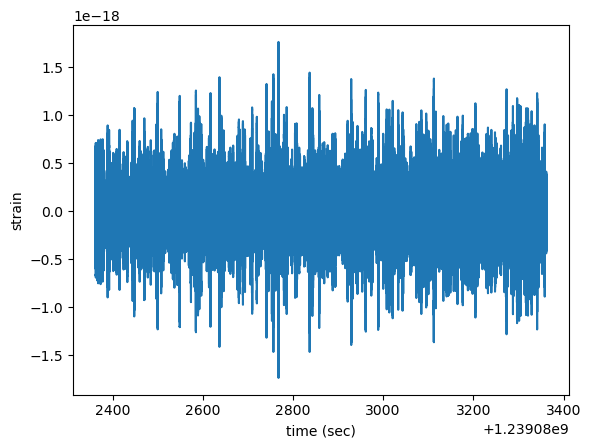

In [2]:
import numpy as np
import pycbc
from pycbc.types import FrequencySeries, TimeSeries
import matplotlib.pyplot as plt

d = np.load('noise_ts_4096Hz.npy')
time = d[:, 0]
d = pycbc.types.TimeSeries(d[:, 1], delta_t = time[1]-
time[0])
data = d
plt.plot(time, data)
plt.xlabel('time (sec)')
plt.ylabel('strain')

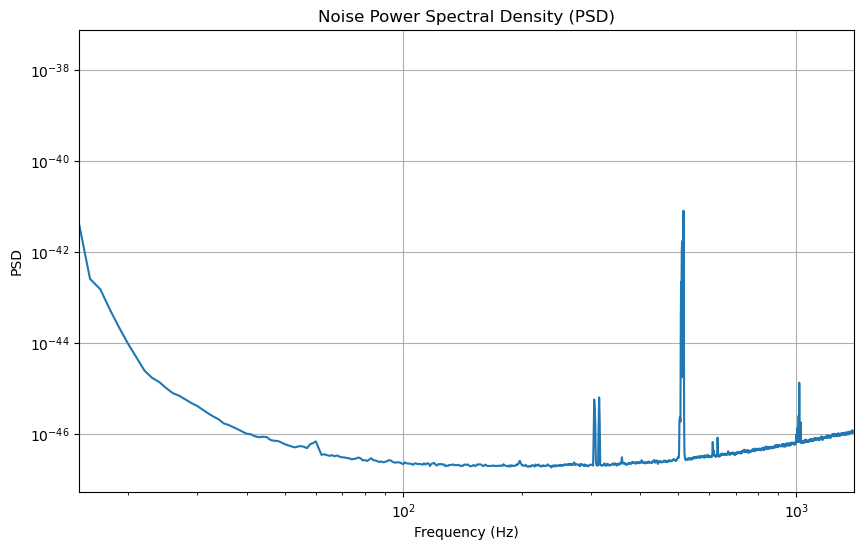

In [4]:
from pycbc.psd import welch, interpolate

psd = welch(data)

# Plot the PSD
plt.figure(figsize=(10, 6))
plt.loglog(psd.sample_frequencies, psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.xlim(15,1400)
plt.title('Noise Power Spectral Density (PSD)')
plt.grid(True)
plt.show()

In [13]:
data.delta_t #checking delta t

0.000244140625

Maximum SNR for mass 5: 1.0033035160150535e-19


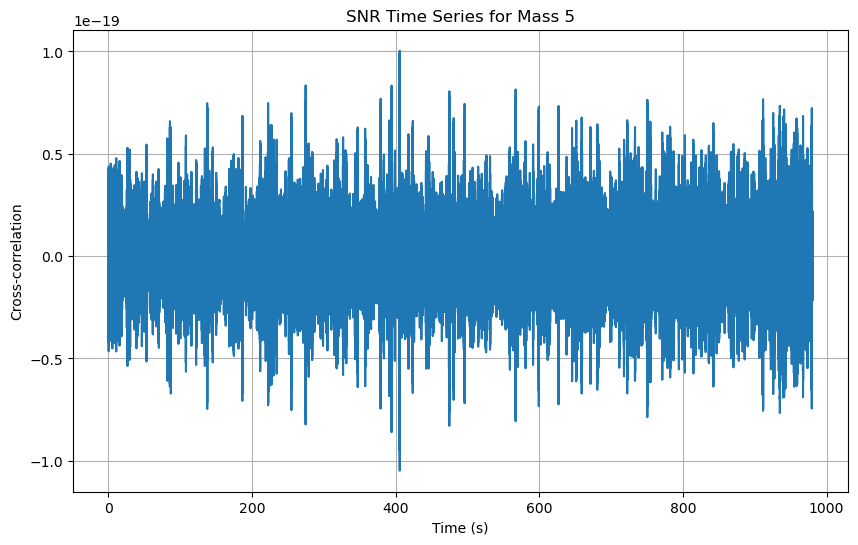

Maximum SNR for mass 6: 1.1887277253356833e-19


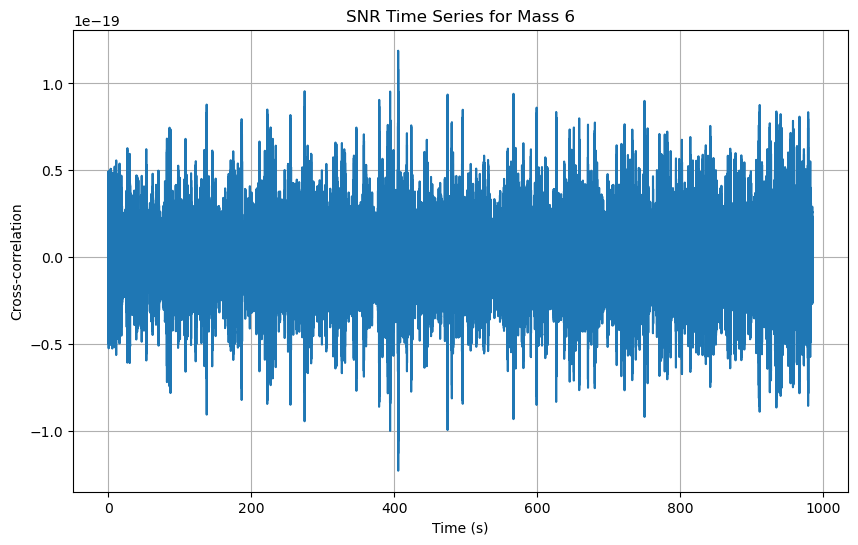

Maximum SNR for mass 7: 1.3641806157154487e-19


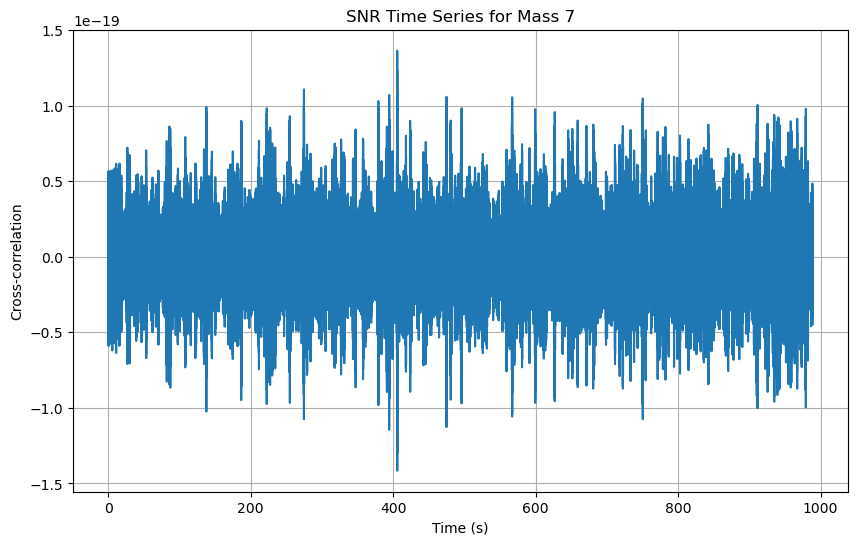

Maximum SNR for mass 8: 1.5326349464736644e-19


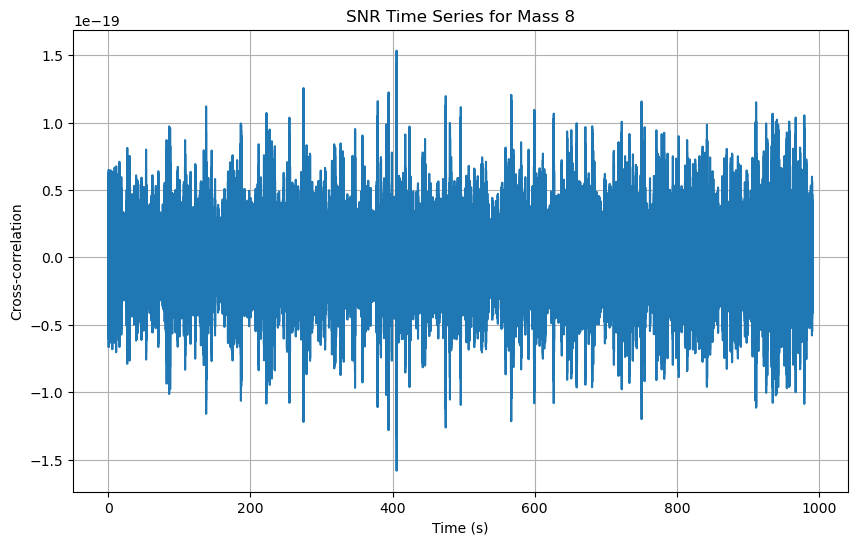

Maximum SNR for mass 9: 1.7307390081609492e-19


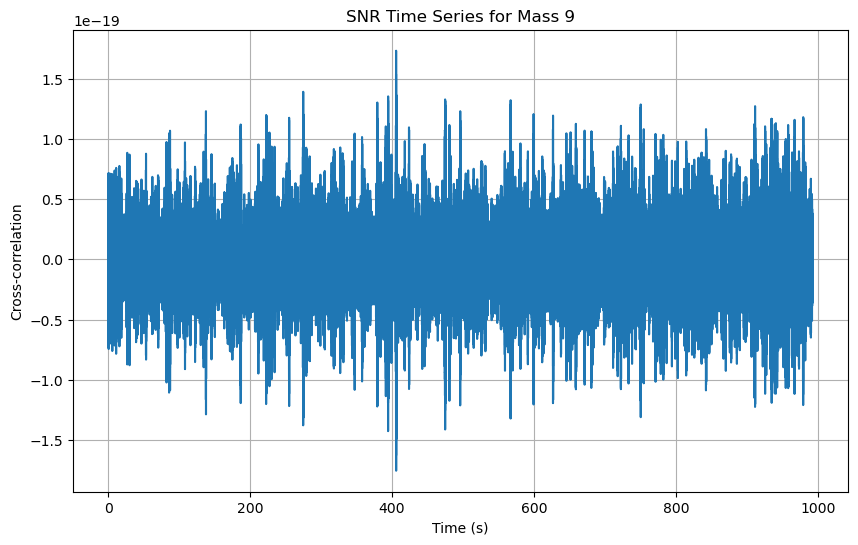

Maximum SNR for mass 10: 1.8762037261871672e-19


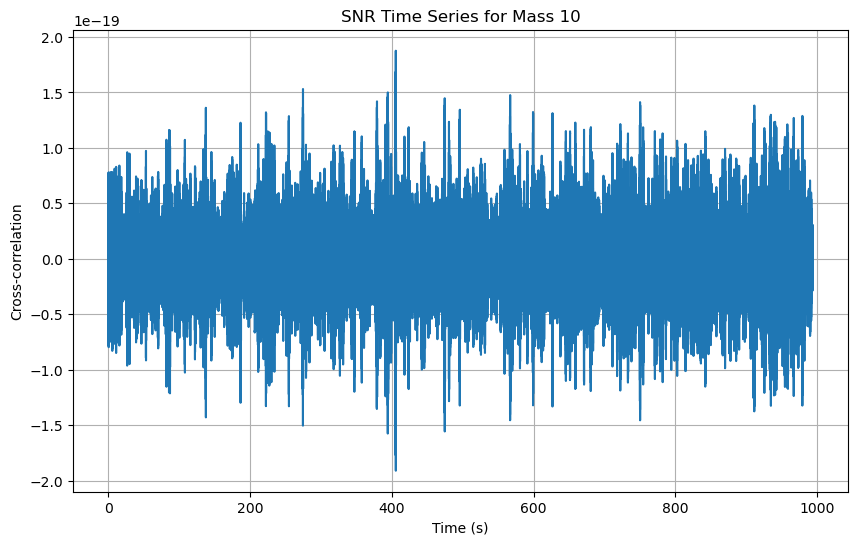

In [38]:
from pycbc.waveform import get_td_waveform
import numpy as np 
#generating template waveforms  with mass between 5-10
masses = range(5, 11)

#Iterate over each mass
for mass in masses:
    # Generate waveform for the current mass
    hp, _ = get_td_waveform(approximant="SEOBNRv4_opt",
                             mass1=mass,
                             mass2=mass,
                             delta_t=0.000244140625,
                             f_lower=20)
    
    #Normalize the template waveform
    hp = hp / max(np.correlate(hp, hp, mode='full')) ** 0.5
    
    #Calculate the cross-correlation
    cross_correlation = np.zeros(len(data) - len(hp))
    hp_numpy = hp.numpy()
    data_array = data.numpy()
    for i in range(len(data) - len(hp_numpy)):
        cross_correlation[i] = (hp_numpy * data_array[i:i+len(hp_numpy)]).sum()
        
    #Find the maximum SNR value
    max_snr = np.max(cross_correlation)
    print(f"Maximum SNR for mass {mass}: {max_snr}")
    
    #Plot the SNR time series for the current mass
    plt.figure(figsize=(10, 6))
    times = np.arange(len(data) - len(hp_numpy)) / 4096
    plt.plot(times, cross_correlation)
    plt.xlabel('Time (s)')
    plt.ylabel('Cross-correlation')
    plt.title(f'SNR Time Series for Mass {mass}')
    plt.grid(True)
    plt.show()
    
    #no detection of GW

In [5]:
import pycbc.noise
import pycbc.psd

psd = welch(data)

white_data = (data.to_frequencyseries() / psd**0.5).to_timeseries()


ValueError: different delta_f

In [ ]:
#define variables
data_length = len(data)
sample_rate = 4096

# The PSD, sampled properly for the noisy data
flow = 10.0
delta_f = 1.0 / data_length
flen = int(sample_rate / (2 * delta_f)) + 1
psd_td = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The 0th and Nth values are zero. Set them to a nearby value to avoid dividing by zero.
psd_td[0] = psd_td[1]
psd_td[len(psd_td) - 1] = psd_td[len(psd_td) - 2]

##This is how far I got, did not finnish the histogram plot###
